In [1]:
import pandas as pd 
import torch
import numpy as np
import random
import os
from matplotlib import pyplot as plt

def set_seed(seed: int = 42) -> None:
    """Sets the random seed for reproducibility across PyTorch, NumPy, and Python's random module."""
    os.environ['PYTHONHASHSEED'] = str(seed)  # For Python's hash seed
    torch.manual_seed(seed)  # For PyTorch's CPU and CUDA RNGs
    torch.cuda.manual_seed(seed)  # For CUDA devices specifically
    torch.cuda.manual_seed_all(seed) # For all CUDA devices if multiple are used
    np.random.seed(seed)  # For NumPy's random number generator
    random.seed(seed)  # For Python's built-in random module

    # For deterministic algorithms in PyTorch (optional, but recommended for full reproducibility)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Example usage:
set_seed(123)

In [2]:
import sys
import os

# Add project root (parent of "src") to Python path
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_OhioT1DM

Ohio_PATH = "..\data\\raw\\"
X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = load_OhioT1DM(path=Ohio_PATH, look_back=128, test_size = None)
X_test, y_reg_test, y_clf_test = load_OhioT1DM(path=Ohio_PATH, look_back=128, train=False)

In [12]:
import glob 
import re

generated_PATH = "..\data\\generated\\synth_**.pt"

generated_paths  = glob.glob(generated_PATH) 

pattern = r"synth_(\w+)\.pt"  # capture word characters between 'synth_' and '.pt'

generated_data = {}

for path in generated_paths: 
    
    data = torch.load(path, weights_only=False)
    file_name = path.split("\\")[-1]
    match = re.search(pattern, file_name)
    generator = match.group(1)
    data = data.clip(40, 400)
    generated_data[generator] = np.array(data.detach().cpu()).reshape(-1, 128)
        
    print(f"synth data generated by {generator} loaded: {file_name} .")



synth data generated by ddpm loaded: synth_ddpm.pt .
synth data generated by gan loaded: synth_gan.pt .
synth data generated by nf loaded: synth_nf.pt .
synth data generated by vae loaded: synth_vae.pt .


In [ ]:
MIN = 40
MAX = 400 

function_reverse = lambda t: (t / 2 + 0.5) * (MAX - MIN) + MIN 

In [18]:
Evaluation_results = {} 

Evaluation_results ["StatisticalFidelity"] = {}

In [21]:
X = np.concatenate([X_train, X_val])

## Statistical Fidelity

Higher-Order Statistics: Compare overall behavior

In [24]:
from scipy.stats import skew, kurtosis

Evaluation_results ["StatisticalFidelity"]["HighOredeStats"] = {"Criterions" : ["mean", "std", "skew", "kurtosis"]}
summary = lambda x: [np.mean(x), np.std(x), skew(x), kurtosis(x)]
Evaluation_results ["StatisticalFidelity"]["HighOredeStats"]["OhioT1dm"] = summary(X_train.ravel())

for model, data in generated_data.items(): 
    
    Evaluation_results ["StatisticalFidelity"]["HighOredeStats"][model] = summary(data.ravel())
    print(f"\n{model}")
    print("Real:", summary(X_train.ravel()))
    print("Synth:", summary(data.ravel()))



ddpm
Real: [157.63489, 58.019825, 0.6058438155968802, 0.16030767680529756]
Synth: [176.87314, 63.278816, 0.3845819068068395, -0.1342964235724602]

gan
Real: [157.63489, 58.019825, 0.6058438155968802, 0.16030767680529756]
Synth: [161.04118, 58.336807, 0.6685833186166897, 0.2499627375904856]

nf
Real: [157.63489, 58.019825, 0.6058438155968802, 0.16030767680529756]
Synth: [167.26617, 65.298836, 0.7383798292789239, 0.7247804486136529]

vae
Real: [157.63489, 58.019825, 0.6058438155968802, 0.16030767680529756]
Synth: [125.87941, 10.491634, 0.2101889192119734, -0.03080852740087492]


Marginal Distribution Comparison: Compare glucose range/shape

In [27]:
from scipy.stats import ks_2samp
import numpy as np

Evaluation_results ["StatisticalFidelity"]["KS_Test"] = {"Criterions" : ["ks_stat", "p_val"]}


for model, data in generated_data.items(): 
    
    ks_stat, p_val = ks_2samp(X_train.ravel(), data.ravel())
    Evaluation_results ["StatisticalFidelity"]["KS_Test"][model] = [ks_stat, p_val]
    print(f"KS statistic {model} = {ks_stat:.4f}, p-value = {p_val:.4f}")

KS statistic ddpm = 0.1404, p-value = 0.0000
KS statistic gan = 0.0252, p-value = 0.0000
KS statistic nf = 0.0609, p-value = 0.0000
KS statistic vae = 0.5022, p-value = 0.0000


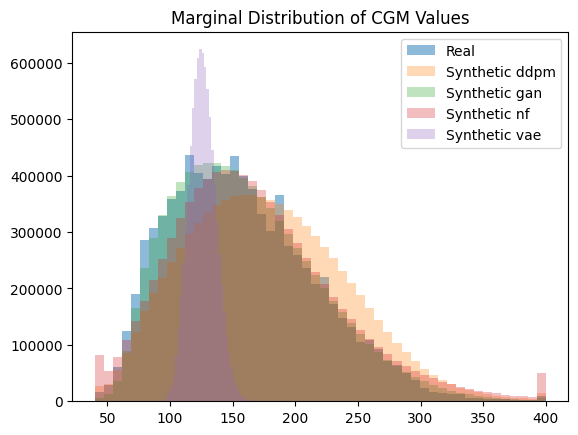

In [29]:
import matplotlib.pyplot as plt

plt.hist(X_train.ravel(), bins=50, alpha=0.5, label="Real")
for model, data in generated_data.items(): 
    plt.hist(data.ravel(), bins=50, alpha=0.3, label=f"Synthetic {model}")
plt.legend(); plt.title("Marginal Distribution of CGM Values")
plt.show()


Temporal Dependence (Dynamics): Check lag dependencies

ACF difference ddpm: 0.3127
ACF difference gan: 0.3865
ACF difference nf: 0.0912
ACF difference vae: 1.7540


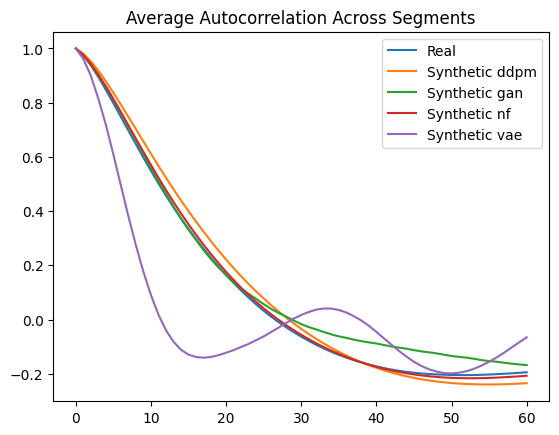

In [31]:
from statsmodels.tsa.stattools import acf

Evaluation_results ["StatisticalFidelity"]["TemporalDependence"] = {"Criterions" : ["acf_diff"]}

def mean_acf(X, nlags=60):
    acfs = []
    for row in X:
        acfs.append(acf(row, nlags=nlags))
    return np.mean(acfs, axis=0)

acf_real = mean_acf(X_train)
plt.plot(acf_real, label="Real")

for model, data in generated_data.items(): 
    acf_synth = mean_acf(data)
    acf_diff = np.linalg.norm(acf_real - acf_synth)
    Evaluation_results ["StatisticalFidelity"]["TemporalDependence"][model] = [acf_diff]
    print(f"ACF difference {model}: {acf_diff:.4f}")
    plt.plot(acf_synth, label=f"Synthetic {model}")



plt.legend(); plt.title("Average Autocorrelation Across Segments")
plt.show()


Spectral Properties (Frequency Domain): Compare periodicity

PSD difference ddpm: 32729.2539
PSD difference gan: 15867.9395
PSD difference nf: 21202.7969
PSD difference vae: 122726.6953


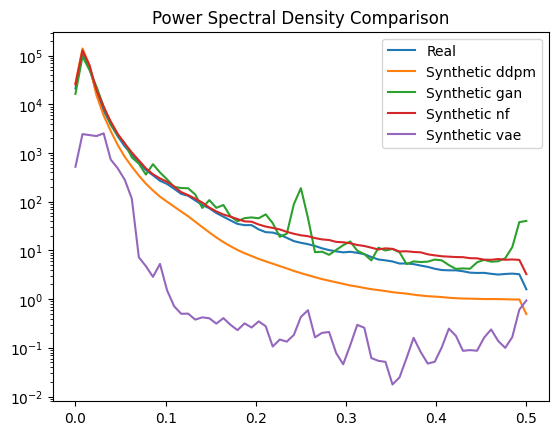

In [37]:
from scipy.signal import welch

Evaluation_results ["StatisticalFidelity"]["SpectralProperties"] = {"Criterions" : ["PSD_diff"]}

f_real, Pxx_real = welch(X_train, nperseg=128)
plt.semilogy(f_real, Pxx_real.mean(axis=0), label='Real') 
psd_real = Pxx_real.mean(axis=0).ravel()

for model, data in generated_data.items(): 
    f_synth, Pxx_synth = welch(data, nperseg=128)
    psd_synth = Pxx_synth.mean(axis=0).ravel()
    psd_diff = np.linalg.norm(psd_real - psd_synth) 
    Evaluation_results ["StatisticalFidelity"]["SpectralProperties"][model] = [psd_diff]
    print(f"PSD difference {model}: {psd_diff:.4f}")
    plt.semilogy(f_synth, psd_synth, label=f'Synthetic {model}')
    

plt.legend(); plt.title("Power Spectral Density Comparison")
plt.show()


In [38]:
Evaluation_results

{'StatisticalFidelity': {'HighOredeStats': {'Criterions': ['mean',
    'std',
    'skew',
    'kurtosis'],
   'OhioT1dm': [157.63489, 58.019825, 0.6058438155968802, 0.16030767680529756],
   'ddpm': [176.87314, 63.278816, 0.3845819068068395, -0.1342964235724602],
   'gan': [161.04118, 58.336807, 0.6685833186166897, 0.2499627375904856],
   'nf': [167.26617, 65.298836, 0.7383798292789239, 0.7247804486136529],
   'vae': [125.87941, 10.491634, 0.2101889192119734, -0.03080852740087492]},
  'KS_Test': {'Criterions': ['ks_stat', 'p_val'],
   'ddpm': [0.1403599791410407, 0.0],
   'gan': [0.02521924137113385, 0.0],
   'nf': [0.06089389717977978, 0.0],
   'vae': [0.5022396520295804, 0.0]},
  'TemporalDependence': {'Criterions': ['acf_diff'],
   'ddpm': [0.3126958536817439],
   'gan': [0.3865179625901892],
   'nf': [0.09116655165836414],
   'vae': [1.7539589369644548]},
  'SpectralProperties': {'Criterions': ['PSD_diff'],
   'ddpm': [32729.254],
   'gan': [15867.939],
   'nf': [21202.797],
   'vae

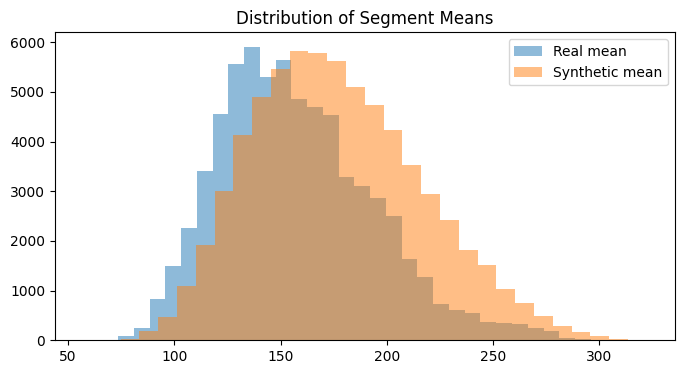

KS mean=0.202, KS var=0.086


In [35]:
mean_real = X_train.mean(axis=1)
mean_synth = data.mean(axis=1)

var_real = X_train.var(axis=1)
var_synth = data.var(axis=1)

plt.figure(figsize=(8,4))
plt.hist(mean_real, bins=30, alpha=0.5, label="Real mean")
plt.hist(mean_synth, bins=30, alpha=0.5, label="Synthetic mean")
plt.legend(); plt.title("Distribution of Segment Means")
plt.show()

ks_mean, _ = ks_2samp(mean_real, mean_synth)
ks_var, _  = ks_2samp(var_real, var_synth)
print(f"KS mean={ks_mean:.3f}, KS var={ks_var:.3f}")
